# Customer Segmentation Using KMeans Clustering

## Project Overview

This project performs customer segmentation using **unsupervised learning**. 
Unlike supervised learning, there is no target variable to predict. Instead, 
the goal is to discover groups of customers with similar characteristics.

The dataset contains customer information such as:

- Age
- Annual Income
- Spending Score

KMeans clustering is used to identify meaningful customer segments based on 
these features.

### Objectives

- Explore and understand the customer dataset
- Perform exploratory data analysis (EDA)
- Scale the clustering features
- Apply KMeans clustering with different numbers of clusters
- Use the Elbow Method to select an appropriate number of clusters
- Profile and interpret the resulting customer segments
- Use PCA to visualize the clusters in two dimensions
- Save the final clustering model and scaler for future use

## Project Workflow

The project follows this workflow:

**Data Loading → Data Exploration → EDA → Feature Selection → Scaling → 
KMeans Experimentation → Elbow Method → Final Clustering → Cluster Profiling 
→ PCA Visualization → Model Saving**

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

## 1. Load the Dataset

The dataset contains demographic and spending information for mall customers.

Before performing clustering, the data will be inspected for its structure,
data types, missing values, and duplicate records.

In [4]:
DATA_PATH = "../data/Mall_Customers.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print(f"Dataset contains {df.shape[0]} customers and {df.shape[1]} columns.")

Dataset contains 200 customers and 5 columns.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0


### Initial Data Observations

The dataset is checked for missing values and duplicate records before 
proceeding with analysis. No Duplizates and missing values found. The customer identifier is retained for reference 
but will not be used as a clustering feature because it does not describe 
customer behavior.

In [9]:
df.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

## 2. Feature Selection

For customer segmentation, the following numerical features are selected:

- **Age** – customer demographic information
- **Annual Income (k$)** – approximate annual income
- **Spending Score (1-100)** – spending behavior assigned by the mall

`CustomerID` is excluded because it is only an identifier and has no 
meaningful relationship with customer similarity.

Gender will be explored during EDA but is not included in the KMeans model 
to keep the segmentation focused on the numerical behavioral and demographic 
variables specified for this project.

In [10]:
features = [
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]

X = df[features]
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## 3. Exploratory Data Analysis

EDA is performed to understand the distributions of the variables and identify
patterns that may help explain the customer segments discovered later.

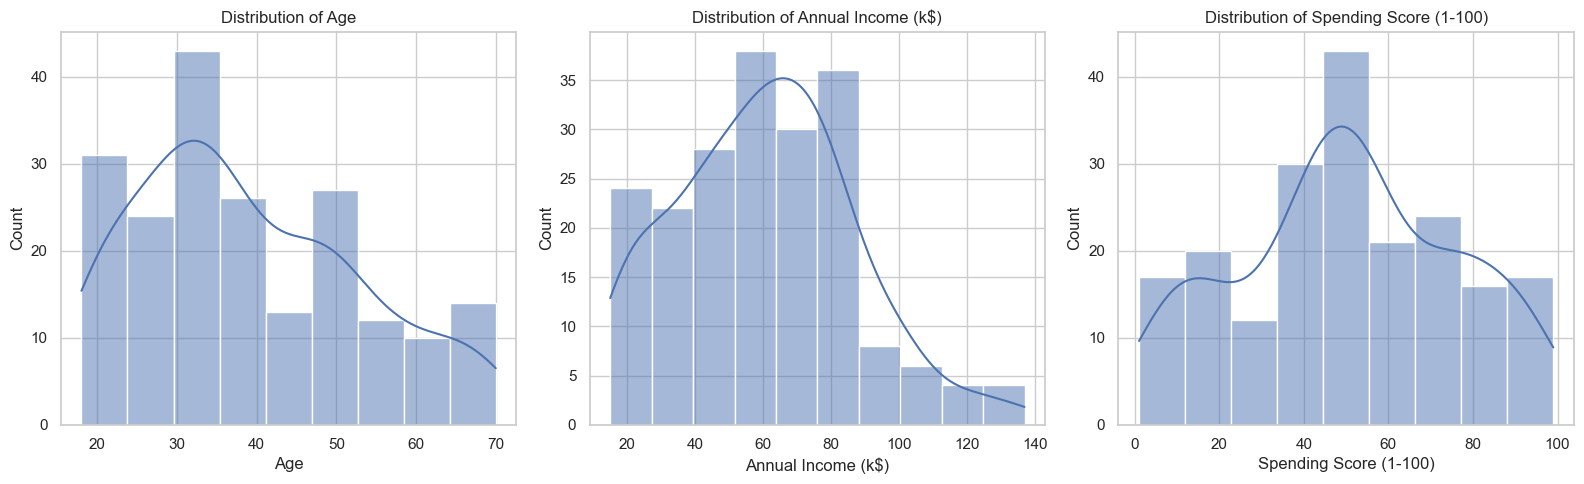

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feature in zip(axes, features):
    sns.histplot(data=df, x=feature, kde=True, ax=ax)
    ax.set_title(f"Distribution of {feature}")
plt.savefig(
    "../visualizations/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

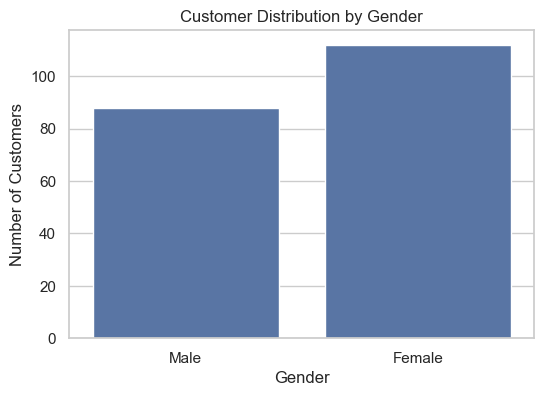

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Gender")
plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.savefig(
    "../visualizations/customer_distribution_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

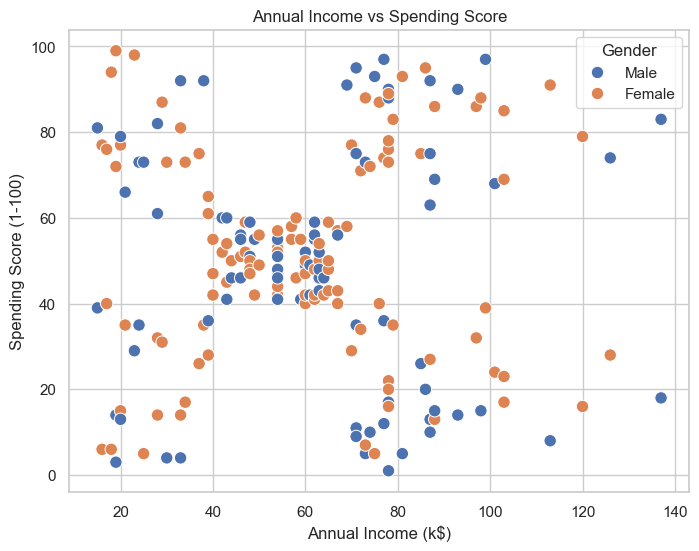

In [16]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Annual Income vs Spending Score")
plt.show()

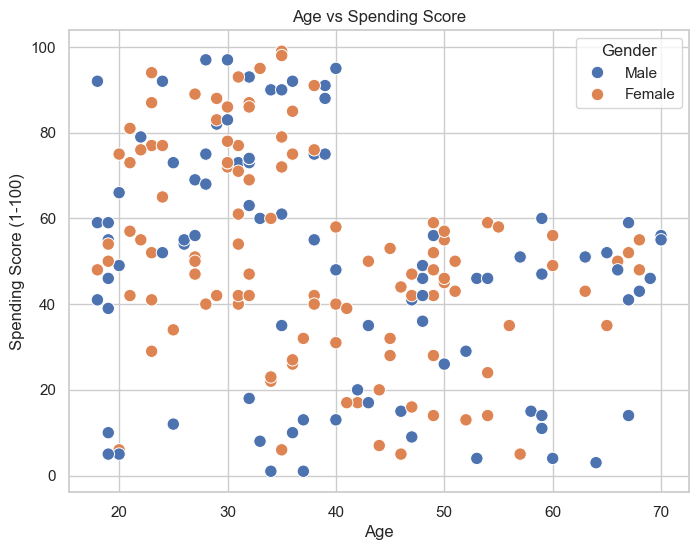

<Figure size 640x480 with 0 Axes>

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)",
    hue="Gender",
    s=80
)

plt.title("Age vs Spending Score")
plt.show()
plt.savefig(
    "../visualizations//income_vs_spending_eda.png",
    dpi=300,
    bbox_inches="tight"
)

### EDA Observations

The distributions show variation in customer age, income, and spending 
behavior. The scatter plots also indicate that customers do not form a 
single homogeneous group. Differences in income and spending behavior 
suggest that clustering may reveal distinct customer segments.

The observed patterns provide motivation for applying an unsupervised 
clustering algorithm.

## 4. Feature Scaling

KMeans clustering is distance-based, so features with larger numerical 
scales can have a greater influence on the clustering process.

StandardScaler is therefore used to transform the selected features so that 
they are on a comparable scale.

The scaler will also be saved later because the same transformation must be 
applied to any new customer data before making cluster assignments.

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features,
    index=df.index
)

X_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


## 5. KMeans Clustering

KMeans divides observations into a predefined number of clusters.

The algorithm works by:

1. Selecting initial cluster centroids
2. Assigning each customer to the nearest centroid
3. Updating the centroids based on the assigned customers
4. Repeating the process until the cluster assignments stabilize

Since the appropriate number of clusters is not known beforehand, several 
values of K will be evaluated.

In [22]:
k_range = range(2, 11)
inertias = []

for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    inertias.append(model.inertia_)

print("Inertia values:")
for k, inertia in zip(k_range, inertias):
    print(f"K = {k}: Inertia = {inertia:.2f}")

Inertia values:
K = 2: Inertia = 389.39
K = 3: Inertia = 295.21
K = 4: Inertia = 205.23
K = 5: Inertia = 168.25
K = 6: Inertia = 133.87
K = 7: Inertia = 117.01
K = 8: Inertia = 103.87
K = 9: Inertia = 93.09
K = 10: Inertia = 82.39


## 6. Elbow Method

The Elbow Method evaluates how within-cluster variation changes as the 
number of clusters increases.

**Inertia** measures the total squared distance between each observation 
and its assigned cluster centroid.

As K increases, inertia generally decreases. The goal is to identify a 
point where adding additional clusters produces a noticeably smaller 
improvement. This point is referred to as the "elbow."

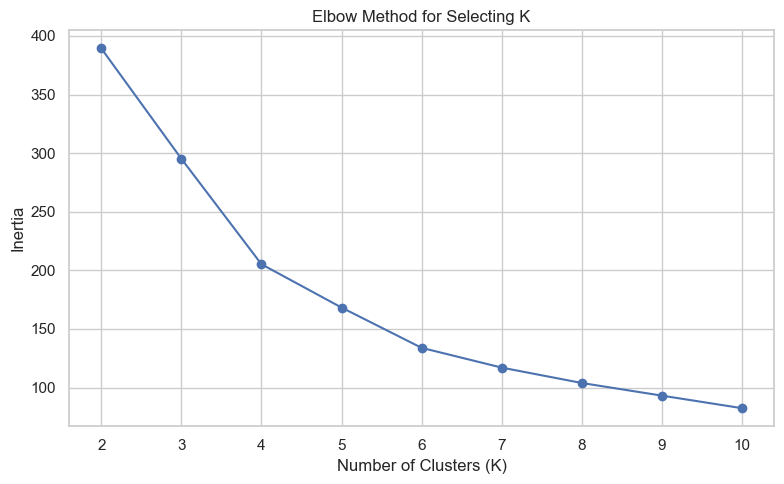

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Selecting K")
plt.xticks(list(k_range))
plt.tight_layout()
plt.savefig(
    "../visualizations//elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The inertia decreases substantially from K=2 to K=4. After K=5, the 
reduction in inertia becomes progressively smaller, indicating diminishing 
returns from adding additional clusters.

Based on this trade-off between cluster compactness and model simplicity, 
**K=5 was selected as the final number of clusters**.